In [1]:
# ============================================================
# [0] MNIST 데이터셋 로드
# ============================================================
# 💡 MNIST = "Hello World of ML"
# - 28×28 픽셀 크기의 손글씨 숫자(0~9) 이미지 70,000장
# - fetch_openml로 OpenML에서 다운로드
# - as_frame=False: DataFrame이 아닌 NumPy 배열로 받음 (이미지는 배열이 편함)
# ============================================================

from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [2]:
# [1] 특성(X)과 레이블(y) 분리
#     - X: 픽셀값 배열 (각 행이 하나의 이미지)
#     - y: 숫자 레이블 (문자열 '0'~'9')

X, y = mnist.data, mnist.target

X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [3]:
# [2] X의 shape 확인 → (70000, 784)
#     - 70,000장 이미지, 각각 784개 픽셀 (28 × 28 = 784)

X.shape

(70000, 784)

In [4]:
# [3] y 확인 → 문자열로 저장된 숫자 레이블
#     ⚠️ y는 문자열이라 y == '5' 같이 비교해야 함 (y == 5 X)

y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [5]:
# [4] y.shape → (70000,) 1차원 배열

y.shape

(70000,)

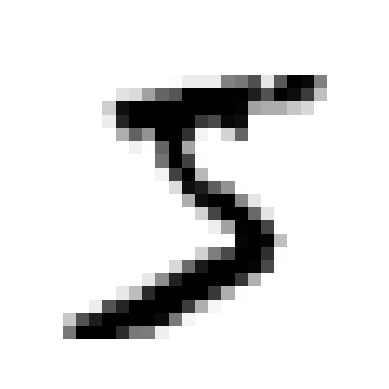

In [6]:
# ============================================================
# [5] 💡 이미지 시각화 함수 정의
# ============================================================
# - reshape(28, 28): 1차원 784픽셀 → 2차원 28×28 이미지
# - cmap="binary": 흑백 컬러맵 (0=흰색, 255=검정)
# - X[0]은 첫 번째 이미지 (결과: 숫자 5)
# ============================================================

import matplotlib.pyplot as plt

def plot_digit(image_data):
  image = image_data.reshape(28, 28)
  plt.imshow(image, cmap="binary")
  plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [7]:
# [6] 첫 번째 이미지의 실제 레이블 확인 → '5'

y[0]

'5'

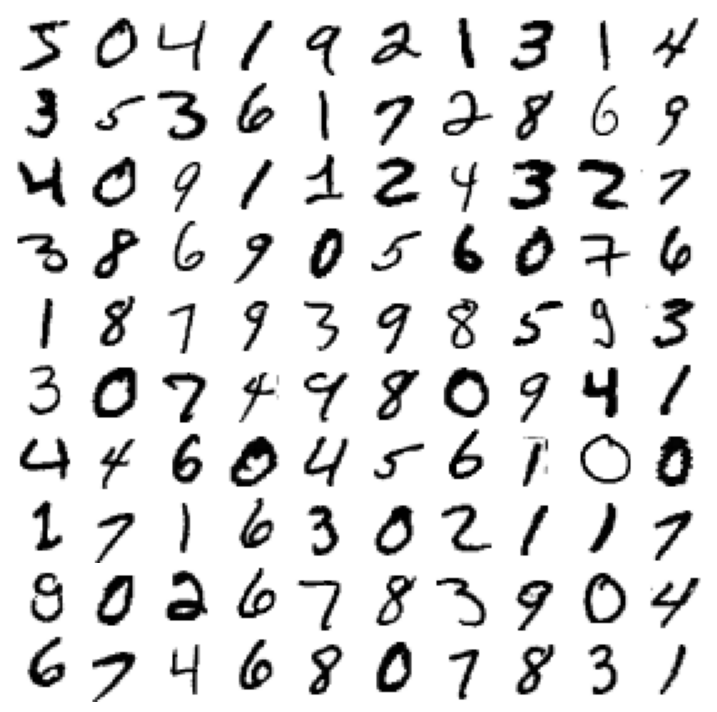

In [8]:
# [7] 💡 100개 이미지 한꺼번에 보기 (10×10 그리드)
#     - 데이터 다양성을 직관적으로 확인
#     - subplots_adjust(wspace=0, hspace=0): 이미지 사이 간격 제거

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
  plt.subplot(10, 10, idx+1)
  plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

In [9]:
# ============================================================
# [8] 🔑 훈련/테스트 세트 분할
# ============================================================
# 💡 MNIST는 이미 섞여 있고 앞 60000개가 훈련, 뒤 10000개가 테스트로 약속됨
# - train_test_split 없이 단순 슬라이싱으로 분할 가능
# - 일반적인 데이터셋에서는 꼭 train_test_split이나 StratifiedKFold 사용!
# ============================================================

X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [10]:
# ============================================================
# [9] 🔑 이진 분류 문제로 단순화: "숫자 5인가, 아닌가?"
# ============================================================
# 💡 10개 클래스(0~9) 대신 2개 클래스로 축소해서 개념부터 학습
# - y_train_5: True(5) 또는 False(5 아님)의 불리언 배열
# - 이렇게 변환하면 이진 분류기로 처리 가능
# ============================================================

y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [11]:
# ============================================================
# [10] 🔑 SGDClassifier - 확률적 경사 하강법 분류기
# ============================================================
# 💡 특징:
# - 큰 데이터셋에 효율적 (온라인 학습 가능)
# - 한 번에 샘플 하나씩 처리
# - random_state=42: 재현성 보장
#
# predict([some_digit]) → array([ True])
# 첫 번째 이미지(실제 5)를 5라고 올바르게 예측!
# ============================================================

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)
sgd_clf.predict([some_digit])

array([ True])

In [12]:
# ============================================================
# [11] 🔑 교차 검증으로 정확도 측정
# ============================================================
# 💡 결과: 약 0.95 이상의 높은 정확도
# ⚠️ 하지만 이 정확도에 속지 마세요! (다음 셀에서 증명)
# ============================================================

from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [13]:
# ============================================================
# [12] 💡 DummyClassifier - 아주 멍청한 기준선(baseline) 모델
# ============================================================
# - 기본 전략: 가장 빈도 높은 클래스를 무조건 예측
# - MNIST에서 5가 아닌 이미지가 약 90% → 모두 "5가 아니다"라고 예측
# - any(...) 결과 False: True가 하나도 없음 → 전부 False 예측
# ============================================================

from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [14]:
# ============================================================
# [13] 🚨 정확도의 함정(Accuracy Paradox)
# ============================================================
# DummyClassifier도 90% 이상 정확도!
#
# 💡 이유: 전체의 약 10%만 '5'이므로, "5가 아니다"만 찍어도 90% 맞힘
#
# ⚠️ 교훈: 불균형 데이터에서는 정확도(accuracy)가 무의미할 수 있음
#        → 정밀도, 재현율, F1 같은 다른 지표 필요!
# ============================================================

cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

In [15]:
# ============================================================
# [14] 🔑 cross_val_predict - 교차 검증으로 "예측값" 얻기
# ============================================================
# 💡 cross_val_score vs cross_val_predict
# - cross_val_score: 각 폴드의 점수(숫자)를 반환
# - cross_val_predict: 각 샘플의 예측값을 반환 (검증 폴드였을 때 예측)
#
# → 혼동 행렬, 정밀도, 재현율을 계산하려면 예측값이 필요!
# ============================================================

from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [16]:
# ============================================================
# [15] 🔑 혼동 행렬 (Confusion Matrix) - 분류 성능의 핵심 도구
# ============================================================
# 💡 2×2 행렬 구조 (이진 분류):
#                  예측: 음성      예측: 양성
#     실제: 음성    TN (진짜 음성)  FP (거짓 양성)
#     실제: 양성    FN (거짓 음성)  TP (진짜 양성)
#
# 완벽한 분류기라면 대각선(TN, TP)만 값이 있고 나머지는 0
# ============================================================

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

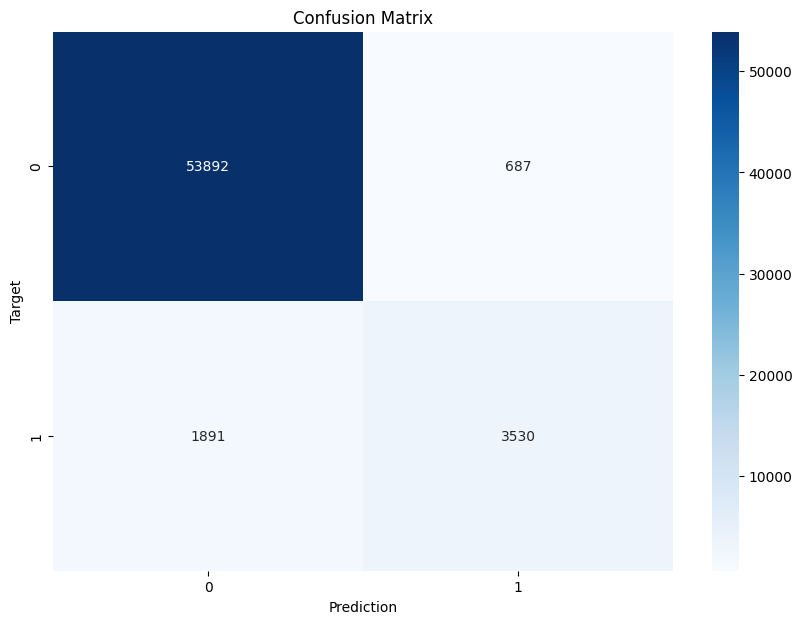

In [17]:
# [16] 💡 seaborn heatmap으로 혼동 행렬 시각화
#      - annot=True: 각 셀에 숫자 표시
#      - fmt="d": 정수 형태로 표시
#      - 숫자가 많고 색이 진할수록 해당 케이스가 많음

import seaborn as sns

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.ylabel('Target')
plt.xlabel('Prediction')
plt.title('Confusion Matrix')
plt.show()

In [18]:
# ============================================================
# [17] 🔑 정밀도 (Precision) = TP / (TP + FP)
# ============================================================
# 💡 "양성이라고 예측한 것 중 실제로 양성인 비율"
# - 거짓 양성(FP)의 비용이 클 때 중요
# - 예: 스팸 필터 (정상 메일을 스팸이라 하면 X)
# ============================================================

from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [19]:
# ============================================================
# [18] 🔑 재현율 (Recall) = TP / (TP + FN)
# ============================================================
# 💡 "실제 양성 중 양성이라고 예측한 비율" (= 민감도)
# - 거짓 음성(FN)의 비용이 클 때 중요
# - 예: 암 진단 (암 환자를 놓치면 X)
# ============================================================

recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [20]:
# ============================================================
# [19] 🔑 F1 Score = 2 × (정밀도 × 재현율) / (정밀도 + 재현율)
# ============================================================
# 💡 정밀도와 재현율의 조화평균
# - 둘 다 높을 때만 F1이 높음 (한쪽이 낮으면 F1도 낮음)
# - 불균형 데이터의 종합 평가 지표로 적합
# ============================================================

from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [21]:
# [20] 💡 classification_report - 여러 지표를 한 번에 요약
#      - precision, recall, f1-score, support(샘플 수) 모두 표시
#      - 각 클래스별로 + 전체 평균

from sklearn.metrics import classification_report
report = classification_report(y_train_5, y_train_pred)
print(report)

              precision    recall  f1-score   support

       False       0.97      0.99      0.98     54579
        True       0.84      0.65      0.73      5421

    accuracy                           0.96     60000
   macro avg       0.90      0.82      0.85     60000
weighted avg       0.95      0.96      0.95     60000



In [22]:
# ============================================================
# [21] 🔑 decision_function - 샘플의 "점수" 얻기
# ============================================================
# 💡 분류기는 내부적으로 각 샘플의 점수를 계산
# - 이 점수가 임곗값(threshold)보다 크면 양성, 작으면 음성
# - predict()는 기본 임곗값 0을 자동 적용
# - decision_function()은 원시 점수를 그대로 반환 → 임곗값 직접 조정 가능!
# ============================================================

y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [23]:
# [22] 기본 임곗값 0으로 분류 → predict()와 동일한 결과

threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [24]:
# ============================================================
# [23] 💡 임곗값을 3000으로 올리면?
# ============================================================
# - 점수가 3000 이상이어야만 양성으로 분류
# - 기준이 엄격해짐 → 정밀도 ↑, 재현율 ↓
# - 이 이미지는 점수가 3000 미만이라 False로 분류됨
# ============================================================

threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [25]:
# ============================================================
# [24] 🔑 교차 검증으로 모든 훈련 샘플의 점수 얻기
# ============================================================
# 💡 method="decision_function":
# - 예측 결과(True/False)가 아니라 원시 점수를 반환
# - 이 점수 배열을 이용해 PR 곡선, ROC 곡선 그리기 가능
# ============================================================

y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

In [26]:
# ============================================================
# [25] 🔑 precision_recall_curve - 모든 임곗값에 대한 PR 계산
# ============================================================
# 💡 반환값:
# - precisions: 각 임곗값에서의 정밀도 배열
# - recalls: 각 임곗값에서의 재현율 배열
# - thresholds: 가능한 임곗값들
#
# → 이 세 배열을 이용해 정밀도/재현율 트레이드오프 시각화
# ============================================================

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

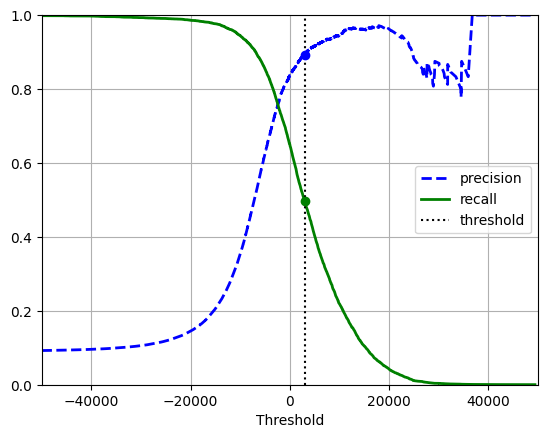

In [27]:
# ============================================================
# [26] 💡 임곗값에 따른 정밀도/재현율 변화 그래프
# ============================================================
# 👁️ 관찰 포인트:
# - 임곗값 ↑ → 정밀도 ↑, 재현율 ↓ (트레이드오프!)
# - 정밀도 곡선은 울퉁불퉁 (TP/FP 비율 변동 때문)
# - 재현율 곡선은 매끄럽게 단조 감소 (분모가 고정되어 있어서)
# ============================================================

plt.plot(thresholds, precisions[:-1], "b--", label="precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
idx = (thresholds >= threshold).argmax()
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.show()

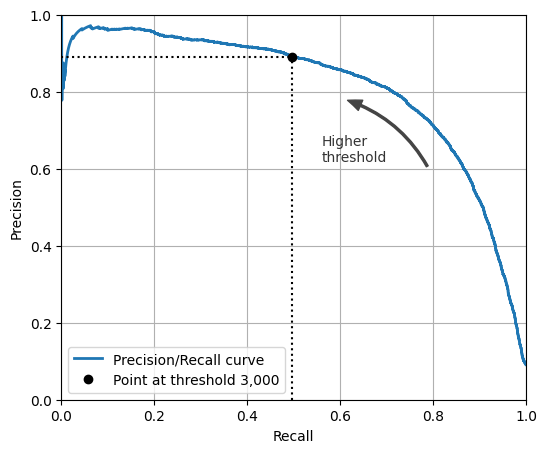

In [28]:
# ============================================================
# [27] 💡 Precision-Recall 곡선 (PR curve)
# ============================================================
# - x축: 재현율, y축: 정밀도
# - 곡선이 우상단(1,1)에 가까울수록 좋은 모델
# - 특정 임곗값 지점을 시각화해서 트레이드오프 확인
# ============================================================

import matplotlib.patches as patches

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3, rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"
))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

In [29]:
# ============================================================
# [28] 🔑 목표 정밀도(90%)를 만족하는 최소 임곗값 찾기
# ============================================================
# 💡 핵심 기법:
# - (precisions >= 0.90): 각 위치가 조건 만족하는지 불리언 배열
# - argmax(): 첫 번째 True의 인덱스 반환 (최초로 90% 도달하는 지점!)
# - thresholds[idx]: 해당 임곗값 추출
#
# → 사업 요구사항 "정밀도 90% 이상" 을 만족하는 임곗값 결정
# ============================================================

idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

In [30]:
# [29] 해당 임곗값으로 다시 예측 → 정밀도 90% 이상 확인

y_train_pred_90 = (y_scores >= threshold_for_90_precision)
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [31]:
# [30] 💡 그때의 재현율 확인
#      정밀도 90%를 위해 재현율이 얼마나 희생됐는지 측정

recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

In [32]:
# ============================================================
# [31] 🔑 ROC 곡선 (Receiver Operating Characteristic)
# ============================================================
# 💡 PR 곡선과 함께 이진 분류 평가의 양대 산맥
# - fpr (False Positive Rate) = FP / (FP + TN) : x축 (오탐율)
# - tpr (True Positive Rate)  = TP / (TP + FN) : y축 (= 재현율)
# ============================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

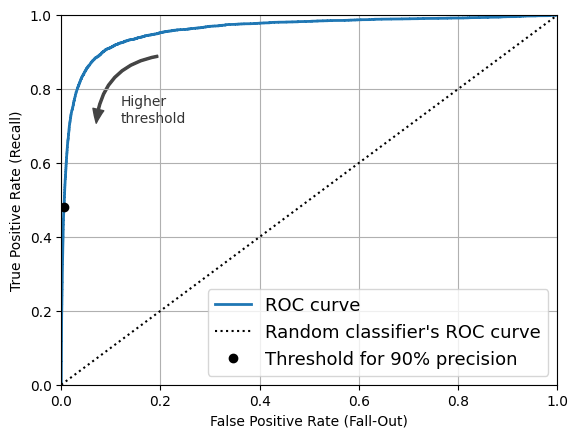

In [33]:
# ============================================================
# [32] 💡 ROC 곡선 시각화
# ============================================================
# 👁️ 핵심 포인트:
# - 점선(0,0)-(1,1): 무작위 분류기 (동전 던지기 수준)
# - 곡선이 좌상단(0,1)에 가까울수록 좋은 모델
# - 곡선 아래 면적(AUC)이 주요 평가 지표
#
# 💡 PR vs ROC 언제 쓰나?
# - 양성 클래스가 드물거나 FP가 중요하면 → PR 곡선
# - 그 외의 경우 → ROC 곡선
# ============================================================

idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0,1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3, rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"
))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
plt.show()

In [34]:
# ============================================================
# [33] 🔑 ROC AUC Score (Area Under Curve)
# ============================================================
# 💡 ROC 곡선 아래 면적 (0 ~ 1 사이 값)
# - 1.0 : 완벽한 분류기
# - 0.5 : 무작위 분류기
# - 보통 0.9 이상이면 훌륭, 0.8대면 양호
# ============================================================

from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

np.float64(0.9604938554008616)

In [35]:
# [34] 💡 더 나은 성능을 위해 RandomForest로 비교
#      랜덤 포레스트는 여러 트리의 앙상블로 보통 SGD보다 성능이 좋음

from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

In [36]:
# ============================================================
# [35] 🔑 method="predict_proba" - 확률 출력
# ============================================================
# 💡 SGDClassifier는 decision_function, RandomForest는 predict_proba 사용
# - predict_proba 결과: [음성 확률, 양성 확률] 형태
# - 첫 번째 샘플: [0.11, 0.89] → 5일 확률 89%
# ============================================================

y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

In [37]:
# [36] 양성 클래스 확률을 "점수"로 사용해 PR 곡선 그리기
#      y_probas_forest[:, 1]: 양성 클래스(5) 확률만 추출

y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest
)

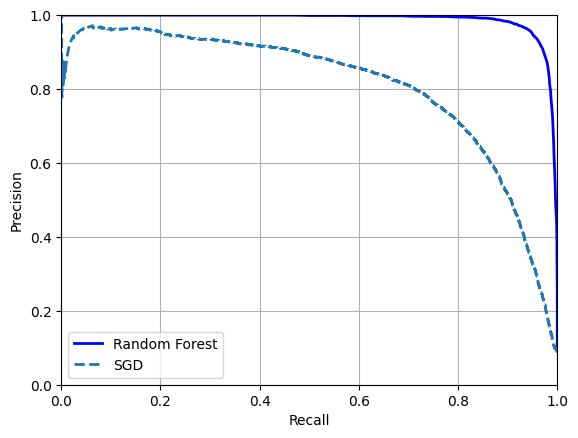

In [38]:
# ============================================================
# [37] 💡 두 모델의 PR 곡선 비교
# ============================================================
# 👁️ 관찰: RandomForest 곡선이 SGD보다 우상단에 가까움
#         → RF가 대부분의 임곗값에서 더 좋은 성능
# ============================================================

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

In [39]:
# [38] RandomForest의 F1 점수 - 확률 0.5를 임곗값으로 사용

y_train_pred_forest = y_probas_forest[:, 1] >= 0.5
f1_score(y_train_5, y_train_pred_forest)

0.9274509803921569

In [40]:
# [39] RandomForest의 ROC AUC - SGD보다 훨씬 높은 값

roc_auc_score(y_train_5, y_scores_forest)

np.float64(0.9983436731328145)

In [41]:
# ============================================================
# [40] 🔑 다중 클래스 분류 시작: SVM으로 10개 클래스 분류
# ============================================================
# 💡 SVM은 기본적으로 이진 분류기지만, 사이킷런이 자동으로 다중 클래스로 확장
#
# SVM이 쓰는 전략: OvO (One-vs-One, 일대일)
# - 0vs1, 0vs2, ... 9vs8 모든 쌍의 분류기 학습 (45개)
# - 가장 많이 이긴 클래스가 최종 예측
#
# X_train[:2000]: SVM은 느려서 2000개만 사용
# ============================================================

from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])
svm_clf.predict([some_digit])

array(['5'], dtype=object)

In [42]:
# ============================================================
# [41] 💡 각 클래스에 대한 결정 점수 확인
# ============================================================
# - 10개 클래스 각각에 대한 점수 반환
# - 가장 높은 점수를 받은 클래스가 최종 예측
# ============================================================

some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

In [43]:
# [42] argmax()로 가장 높은 점수의 클래스 인덱스 찾기

class_id = some_digit_scores.argmax()

In [44]:
# [43] svm_clf.classes_ - 학습된 클래스 목록 확인
#      (문자열로 저장되어 있음: '0', '1', ..., '9')

svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [45]:
# [44] 인덱스로 실제 클래스명 얻기 → 예측 결과 확인

svm_clf.classes_[class_id]

'5'

In [46]:
# ============================================================
# [45] 🔑 OvR (One-vs-Rest, 일대다) 전략 강제 적용
# ============================================================
# 💡 OvR이란?
# - 각 클래스마다 "이 클래스 vs 나머지 전부" 이진 분류기 학습 (10개)
# - 가장 높은 점수의 클래스가 최종 예측
#
# 💡 OvO vs OvR
# - OvR: 분류기 N개 필요 (SGD, 로지스틱 회귀 기본 전략)
# - OvO: 분류기 N×(N-1)/2 개 필요 (SVM 기본 전략)
# - SVM은 훈련 속도가 데이터 크기에 민감해서 OvO가 유리
# ============================================================

from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])
ovr_clf.predict([some_digit])

array(['5'], dtype='<U1')

In [47]:
# [46] 실제로 10개의 분류기가 생성됐는지 확인

len(ovr_clf.estimators_)

10

In [48]:
# ============================================================
# [47] 💡 SGDClassifier는 원래 다중 클래스를 직접 처리 (OvR 내부 사용)
# ============================================================
# - 별도 OvR 래퍼 필요 없음
# - 큰 데이터셋에서 SVM보다 훨씬 빠르게 학습
# ============================================================

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

In [49]:
# [48] 각 클래스에 대한 결정 점수 확인
#      10개 클래스의 점수가 나오는 것을 볼 수 있음

sgd_clf.decision_function([some_digit]).round()

array([[-31893., -34420.,  -9531.,   1824., -22320.,  -1386., -26189.,
        -16148.,  -4604., -12051.]])

In [50]:
# [49] 교차 검증으로 정확도 측정 (스케일링 전)

cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87365, 0.85835, 0.8689 ])

In [51]:
# ============================================================
# [50] 🔑 특성 스케일링의 효과
# ============================================================
# 💡 SGD 같은 경사 하강법 기반 알고리즘은 스케일링에 매우 민감!
# - StandardScaler로 평균 0, 표준편차 1로 변환
# - 단순히 스케일링만으로도 정확도가 크게 상승하는 것을 볼 수 있음
# - .astype("float64"): 정수를 실수로 변환 (스케일러가 실수 필요)
# ============================================================

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.8983, 0.891 , 0.9018])

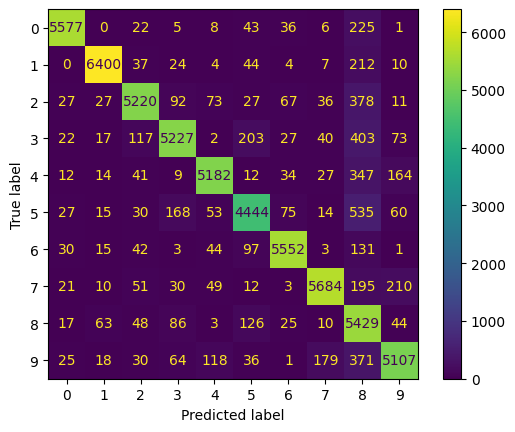

In [52]:
# ============================================================
# [51] 🔑 다중 클래스 혼동 행렬 (10×10)
# ============================================================
# 💡 ConfusionMatrixDisplay.from_predictions - 한 번에 시각화
# - 대각선이 밝을수록 예측 정확
# - 대각선 외 밝은 셀 = 자주 헷갈리는 클래스 쌍
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

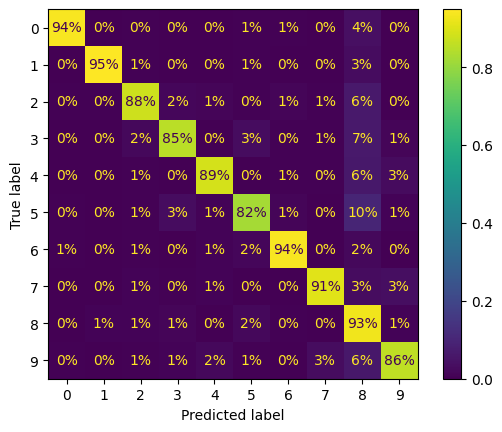

In [53]:
# ============================================================
# [52] 💡 normalize="true"로 행별 정규화
# ============================================================
# - 각 행(실제 클래스)을 100%로 보고 비율 표시
# - 클래스별 샘플 수가 달라도 공정한 비교 가능
# - values_format=".0%": 백분율로 표시
# ============================================================

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        normalize="true", values_format=".0%")
plt.show()

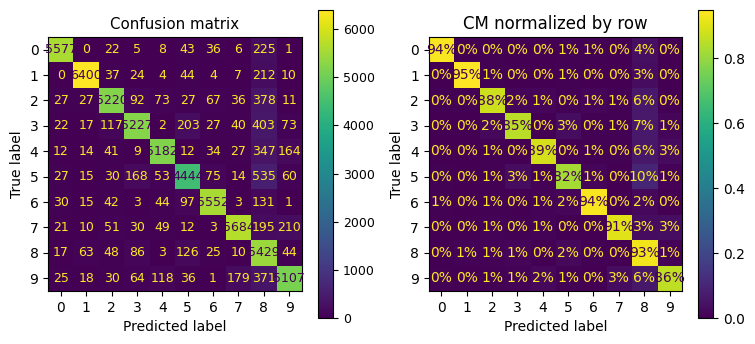

In [54]:
# [53] 💡 원본 카운트 vs 정규화 두 혼동 행렬을 나란히 비교

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=9)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0])
axs[0].set_title("Confusion matrix")
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        normalize="true", values_format=".0%")
axs[1].set_title("CM normalized by row")
plt.show()

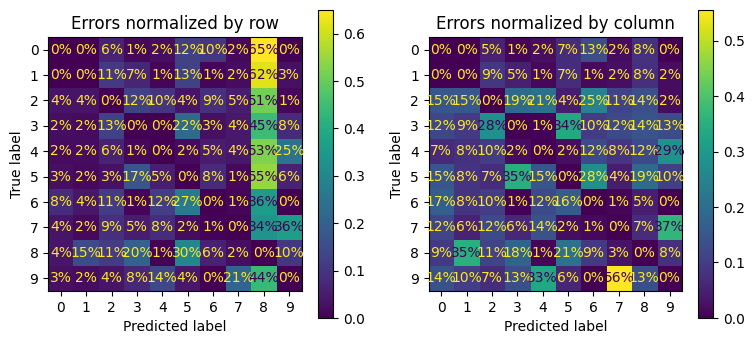

In [55]:
# ============================================================
# [54] 🔑 오류 분석 (Error Analysis) - 어떤 실수를 하는지 파악
# ============================================================
# 💡 sample_weight = (y_train_pred != y_train):
# - 오분류된 샘플에만 가중치 1, 나머지는 0
# - 오류만 모아서 시각화
#
# 👁️ 두 가지 정규화:
# - by row (실제 기준): "실제 X인데 어느 클래스로 잘못 예측됐나"
# - by column (예측 기준): "X로 예측됐는데 실제로는 어느 클래스였나"
#
# → 어떤 전처리/특성 추가가 도움될지 힌트 얻기
# ============================================================

sample_weight = (y_train_pred != y_train)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0], sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
axs[0].set_title("Errors normalized by row")
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1], sample_weight=sample_weight,
                                        normalize="pred", values_format=".0%")
axs[1].set_title("Errors normalized by column")
plt.show()

In [56]:
# ============================================================
# [55] 🔑 헷갈리는 클래스 쌍 샘플 수집 (3과 5)
# ============================================================
# 💡 혼동 행렬에서 자주 헷갈리는 쌍(3↔5)을 발견하면
#    실제 이미지를 모아서 눈으로 확인!
#
# - X_aa: 실제 3, 예측 3 (정답)
# - X_ab: 실제 3, 예측 5 (오답)
# - X_ba: 실제 5, 예측 3 (오답)
# - X_bb: 실제 5, 예측 5 (정답)
# ============================================================

cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

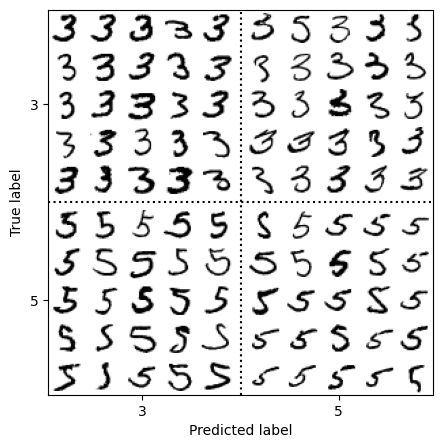

In [57]:
# ============================================================
# [56] 💡 2×2 격자로 시각화: 올바른 예측 vs 잘못된 예측
# ============================================================
# 👁️ 관찰 포인트:
# - 잘못 분류된 3과 5는 사람 눈에도 헷갈릴 만함
# - 선형 모델의 한계: 이미지 위치/회전에 취약
# - 개선 방법: 데이터 증강(shift), CNN 사용 등
# ============================================================

size = 5
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(X_ba, (0, 0)), (X_bb, (1, 0)),
                                       (X_aa, (0, 1)), (X_ab, (1, 1))]:
  for idx, image_data in enumerate(images[:size*size]):
    x = idx % size + label_col * (size + pad)
    y = idx // size + label_row * (size + pad)
    plt.imshow(image_data.reshape(28, 28), cmap="binary", extent=(x, x+1, y, y+1))
plt.xticks([size / 2, size + pad + size / 2], [str(cl_a), str(cl_b)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_b), str(cl_a)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2 * size + pad], "k:")
plt.plot([0, 2 * size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2 * size + pad, 0, 2 * size + pad])
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.show()

In [58]:
# ============================================================
# [57] 🔑 다중 레이블 분류 (Multilabel Classification)
# ============================================================
# 💡 기존 분류 vs 다중 레이블
# - 기존: 하나의 샘플 → 하나의 레이블
# - 다중 레이블: 하나의 샘플 → 여러 레이블 동시에
#
# 예시 (이 코드):
# - 레이블 1: 큰 수인가? (7 이상)
# - 레이블 2: 홀수인가?
# - 숫자 5 → [False(크지 않음), True(홀수)]
#
# np.c_[...]: 여러 배열을 열 방향으로 이어붙이기
# KNN은 다중 레이블 지원 → [[False, True]] 반환
# ============================================================

import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)
knn_clf.predict([some_digit])

array([[False,  True]])

In [59]:
# ============================================================
# [58] 💡 다중 레이블 분류의 F1 점수
# ============================================================
# average="macro":
# - 각 레이블마다 F1 계산 후 단순 평균
# - 모든 레이블을 동등하게 취급
#
# (다른 옵션: "weighted" - 샘플 수로 가중 평균)
# ============================================================

y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9764102655606048

In [60]:
# ============================================================
# [59] 💡 ClassifierChain - 레이블 간 의존성 활용
# ============================================================
# 💡 KNN처럼 다중 레이블을 직접 지원하지 않는 모델(SVC 등)에 사용
# - 레이블을 순서대로 예측하되, 앞선 예측을 다음 예측의 입력으로 사용
# - 레이블 간 상관관계를 학습 가능
# - cv=3: 내부적으로 교차 검증으로 학습
# ============================================================

from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])
chain_clf.predict([some_digit])

array([[0., 1.]])

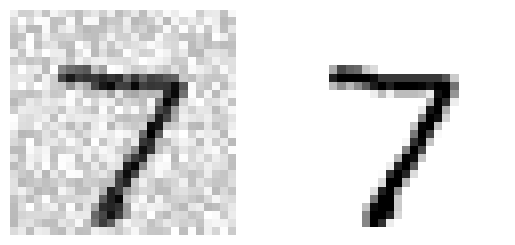

In [61]:
# ============================================================
# [60] 🔑 다중 출력 분류 (Multi-Output Classification)
# ============================================================
# 💡 예제: 노이즈 제거 (이미지 → 이미지)
# - 입력: 노이즈 있는 이미지
# - 출력: 원본 이미지 (각 픽셀이 하나의 "레이블")
# - 784개 레이블 × 각각 0~255 값 = 다중 레이블 + 다중 클래스
#
# np.random.randint(0, 100, ...): 0~99 범위 노이즈 생성
# y_train_mod = X_train: 원본이 곧 타깃 (깨끗한 이미지)
# ============================================================

np.random.seed(42)
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

plt.subplot(121); plot_digit(X_test_mod[0])
plt.subplot(122); plot_digit(y_test_mod[0])

plt.show()

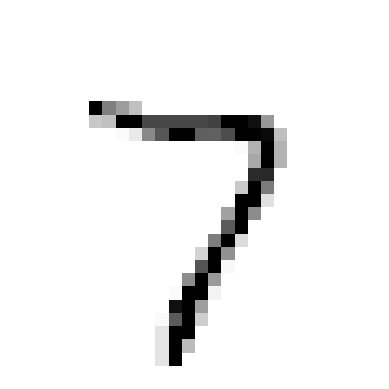

In [62]:
# [61] 💡 KNN으로 노이즈 제거 시도
#      - X_train_mod(노이즈) → y_train_mod(원본) 매핑 학습
#      - 비슷한 노이즈 이미지들의 원본을 평균내서 깨끗한 이미지 복원

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
plt.show()

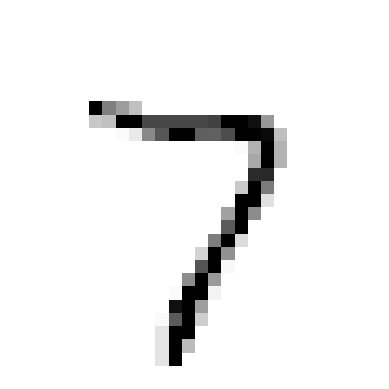

In [63]:
# [62] [61]과 동일한 코드 (복습 or 실수로 중복)

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
plt.show()

In [64]:
# ============================================================
# [63] 🎯 연습문제: KNN으로 97% 이상 정확도 달성하기
# ============================================================
# 💡 1단계: 기본 KNN 성능 측정 (기준선)
# - 하이퍼파라미터 튜닝 전 정확도 확인
# ============================================================

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train)
baseline_accuracy = knn_clf.score(X_test, y_test)
baseline_accuracy

0.9688

In [65]:
# ============================================================
# [64] 🔑 GridSearchCV로 KNN 하이퍼파라미터 튜닝
# ============================================================
# 💡 탐색 대상:
# - weights: "uniform"(균등) vs "distance"(거리 역수로 가중치)
# - n_neighbors: 고려할 이웃 수 (3, 4, 5, 6)
# → 2 × 4 = 8 조합 × cv=5 = 40번 학습
#
# ⚠️ 속도를 위해 10,000개 샘플만 사용 (KNN은 데이터 크면 매우 느림)
# ============================================================

from sklearn.model_selection import GridSearchCV

param_grid = [{'weights': ["uniform", "distance"], 'n_neighbors': [3, 4, 5, 6]}]
knn_clf = KNeighborsClassifier()
grid_search = GridSearchCV(knn_clf, param_grid, cv=5)
grid_search.fit(X_train[:10_000], y_train[:10_000])

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': [3, 4, 5, 6],
                          'weights': ['uniform', 'distance']}])

In [66]:
# [65] 최적 하이퍼파라미터 확인

grid_search.best_params_

{'n_neighbors': 4, 'weights': 'distance'}

In [67]:
# [66] 최적 교차 검증 점수

grid_search.best_score_

np.float64(0.9441999999999998)

In [68]:
# ============================================================
# [67] 💡 최적 모델을 전체 훈련 세트로 재학습 후 테스트
# ============================================================
# - grid_search는 10000개로만 탐색했으니, 최적 설정으로 60000개 전체 학습
# - 보통 튜닝된 모델이 기본 모델보다 정확도 향상
# ============================================================

grid_search.best_estimator_.fit(X_train, y_train)
tuned_accuracy = grid_search.score(X_test, y_test)
tuned_accuracy

0.9714

In [69]:
# ============================================================
# [68] 🔑 데이터 증강 (Data Augmentation)
# ============================================================
# 💡 아이디어: 훈련 이미지를 이동시켜 새 샘플 생성
# - shift(image, [dy, dx]): 이미지를 dy, dx만큼 이동
# - cval=0: 비는 영역을 0(흰색)으로 채움
# - mode="constant": 경계 처리 방식
#
# → 훈련 데이터를 5배로 늘려 모델의 위치 불변성(invariance) 학습
# ============================================================

from scipy.ndimage import shift

def shift_image(image, dx, dy):
  image = image.reshape((28, 28))
  shifted_image = shift(image, [dy, dx], cval = 0, mode="constant")
  return shifted_image.reshape([-1])

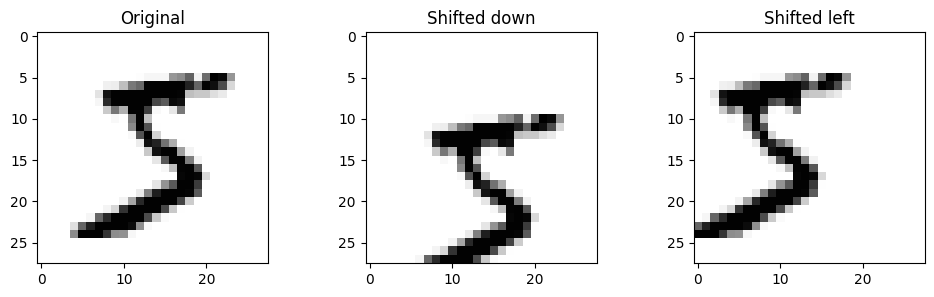

In [70]:
# [69] 💡 이동된 이미지 시각화
#      원본, 아래로 이동, 왼쪽으로 이동 비교

image = X_train[0]
shifted_image_down = shift_image(image, 0, 5)
shifted_image_left = shift_image(image, -5, 0)

plt.figure(figsize=(12, 3))
plt.subplot(131)
plt.title("Original")
plt.imshow(image.reshape(28, 28), cmap="Greys")
plt.subplot(132)
plt.title("Shifted down")
plt.imshow(shifted_image_down.reshape(28, 28), cmap="Greys")
plt.subplot(133)
plt.title("Shifted left")
plt.imshow(shifted_image_left.reshape(28, 28), cmap="Greys")
plt.show()

In [71]:
# ============================================================
# [70] 🔑 훈련 세트 5배로 증강: 원본 + 상하좌우 각 1픽셀 이동
# ============================================================
# 💡 증강 전략:
# - 상하좌우 4방향 × 60,000개 이미지 = 240,000개 추가
# - 원본 포함 총 300,000개 훈련 샘플
# - 이렇게 하면 모델이 위치 변화에 강건해짐
# ============================================================

X_train_augmented = [image for image in X_train]
y_train_augmented = [label for label in y_train]

for dx, dy in ((-1, 0), (1, 0), (0, 1), (0, -1)):
  for image, label in zip(X_train, y_train):
    X_train_augmented.append(shift_image(image, dx, dy))
    y_train_augmented.append(label)

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

In [72]:
# ============================================================
# [71] 🔑 증강된 데이터 섞기 (shuffle)
# ============================================================
# 💡 왜 섞어야 하나?
# - 원본 다음에 이동된 버전이 순서대로 있으면 학습에 편향 발생
# - np.random.permutation: 랜덤 인덱스 생성
# - 같은 인덱스로 X, y 동시에 섞어 대응 관계 유지
# ============================================================

shuffle_idx = np.random.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

In [73]:
# ============================================================
# [72] 🎯 최종 평가: 데이터 증강의 효과 확인
# ============================================================
# 💡 **grid_search.best_params_: 최적 하이퍼파라미터를 그대로 사용
# - 증강된 데이터로 학습한 모델이 원본만 쓴 모델보다
#   일반적으로 정확도가 올라감 (97% 이상 달성 가능)
#
# 🎓 교훈: 모델 튜닝보다 데이터를 늘리는 것이 더 효과적인 경우 많음!
# ============================================================

knn_clf = KNeighborsClassifier(**grid_search.best_params_)
knn_clf.fit(X_train_augmented, y_train_augmented)
augmented_accuracy = knn_clf.score(X_test, y_test)
augmented_accuracy

0.9763